# run - mount drive, install libraries and dependencies

In [1368]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

In [1369]:
# !ls "/research-dataset"

In [1370]:
%pip install hmmlearn
%pip install statsmodels
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1371]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from hmmlearn.hmm import GaussianHMM

# run - pre process env variables

In [1372]:
# Folder path
data_dir = Path("research-dataset")

# Get all CSV files
csv_files = sorted(data_dir.glob("*.csv"))

# List to store dataframes
dfs = []

for file in csv_files:
    df = pd.read_csv(file)

    # Ensure date column is datetime
    df["Date"] = pd.to_datetime(df["Date"])

    dfs.append(df)

# Merge all dataframes on 'date'
from functools import reduce

merged_df = reduce(
    lambda left, right: pd.merge(left, right, on="Date", how="outer"),
    dfs
)

# Sort by date
merged_df = merged_df.sort_values("Date").reset_index(drop=True)
merged_df

,Date,Meridional wind speed,Precipitation rate,Relative humidity,Sea surface temperature,Surface soil moisture,Volumetric soil water layer 1,2 metre temperature,Air temperature,Zonal wind speed
0,2009-01-01,0.201992,1.720000e-08,76.964430,300.84260,0.273302,0.066489,299.36810,298.69098,0.019316
1,2009-02-01,0.306633,1.800000e-08,75.624344,301.09630,0.260608,0.058851,299.66522,299.70657,0.730563
2,2009-03-01,0.111302,6.340000e-08,81.241104,302.46017,0.238888,0.079695,300.23846,299.66962,0.124605
3,2009-04-01,0.173108,7.430000e-08,81.059410,302.75570,0.243174,0.083401,300.97284,300.14917,1.540920
4,2009-05-01,0.188174,1.130000e-07,86.900314,301.67650,0.250756,0.087352,300.43790,300.04160,3.713895
...,...,...,...,...,...,...,...,...,...,...
201,2025-10-01,0.389061,1.940000e-07,83.186480,301.76570,0.177731,0.086967,300.19766,298.89740,1.266329
202,2025-11-01,0.159721,2.020000e-07,82.610980,302.03870,0.195832,0.091008,299.78270,298.55176,-0.267667
203,2025-12-01,-0.032915,9.800000e-08,76.964430,301.30597,0.206945,0.089055,299.36810,298.38250,-0.066906
204,2026-01-01,0.159721,2.020000e-07,82.610980,302.03870,0.195832,0.091008,299.78270,298.55176,-0.267667


In [1373]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Date                           206 non-null    datetime64[ns]
 1   Meridional wind speed          206 non-null    float64       
 2   Precipitation rate             206 non-null    float64       
 3   Relative humidity              206 non-null    float64       
 4   Sea surface temperature        206 non-null    float64       
 5   Surface soil moisture          206 non-null    float64       
 6   Volumetric soil water layer 1  206 non-null    float64       
 7   2 metre temperature            206 non-null    float64       
 8   Air temperature                206 non-null    float64       
 9   Zonal wind speed               206 non-null    float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 16.2 KB


In [1374]:
print(merged_df.isnull().sum())

Date                             0
Meridional wind speed            0
Precipitation rate               0
Relative humidity                0
Sea surface temperature          0
Surface soil moisture            0
Volumetric soil water layer 1    0
2 metre temperature              0
Air temperature                  0
Zonal wind speed                 0
dtype: int64


In [1375]:
merged_df.duplicated(keep=False)

0      False
1      False
2      False
3      False
4      False
       ...  
201    False
202    False
203    False
204    False
205    False
Length: 206, dtype: bool

In [1376]:
merged_df.drop(columns=["Date"]).describe()

,Meridional wind speed,Precipitation rate,Relative humidity,Sea surface temperature,Surface soil moisture,Volumetric soil water layer 1,2 metre temperature,Air temperature,Zonal wind speed
count,206.000000,2.060000e+02,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000,206.000000
mean,-0.164711,9.263495e-08,83.082588,301.497851,0.207102,0.085667,300.126343,299.184097,1.907195
std,0.460666,4.264862e-08,2.457292,0.768418,0.026821,0.007651,0.548387,0.594486,1.727934
min,-1.283917,1.450000e-08,75.624344,299.518950,0.143627,0.056580,298.694460,297.793550,-0.871045
25%,-0.513397,6.435000e-08,81.338092,300.964958,0.190286,0.083406,299.710375,298.758042,0.265126
50%,-0.080125,8.995000e-08,83.648225,301.376485,0.199504,0.088973,300.045670,299.123025,1.513049
75%,0.185919,1.157500e-07,84.957851,301.992298,0.212785,0.090649,300.527975,299.561597,3.667583
max,0.798681,2.530000e-07,87.190926,303.988460,0.305304,0.092461,301.713200,301.399260,4.768369


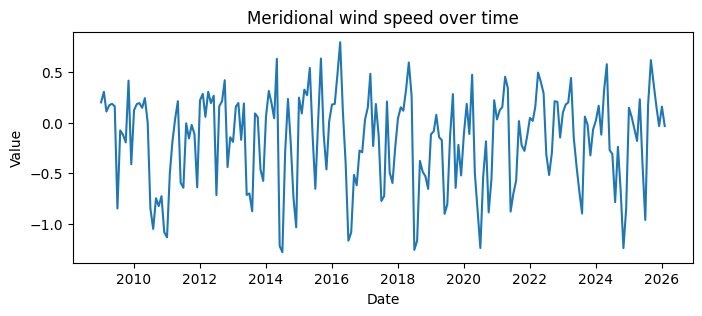

In [1377]:
plt.figure(figsize=(8, 3))
plt.plot(merged_df["Date"], merged_df["Meridional wind speed"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Meridional wind speed over time")
plt.show()

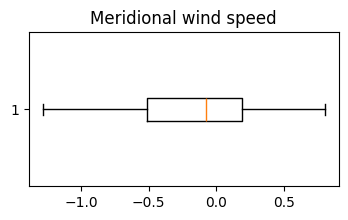

In [1378]:
plt.figure(figsize=(4, 2))
plt.boxplot(merged_df["Meridional wind speed"].dropna(), vert=False)
plt.title("Meridional wind speed")
plt.show()

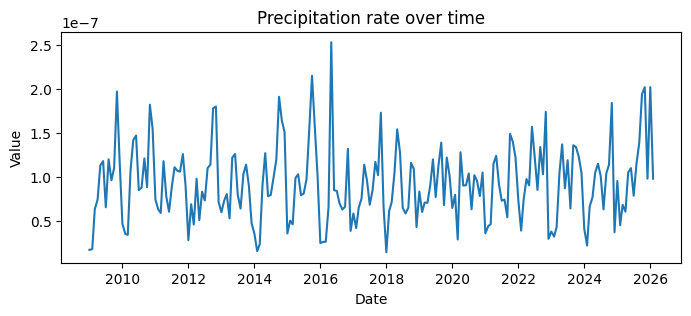

In [1379]:
plt.figure(figsize=(8, 3))
plt.plot(merged_df["Date"], merged_df["Precipitation rate"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Precipitation rate over time")
plt.show()

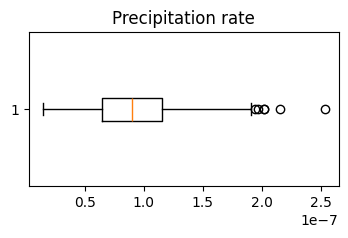

In [1380]:
plt.figure(figsize=(4, 2))
plt.boxplot(merged_df["Precipitation rate"].dropna(), vert=False)
plt.title("Precipitation rate")
plt.show()

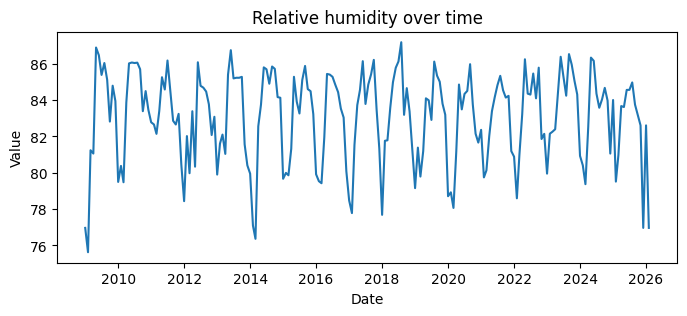

In [1381]:
plt.figure(figsize=(8, 3))
plt.plot(merged_df["Date"], merged_df["Relative humidity"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Relative humidity over time")
plt.show()

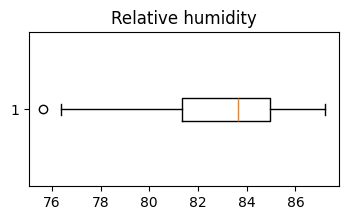

In [1382]:
plt.figure(figsize=(4, 2))
plt.boxplot(merged_df["Relative humidity"].dropna(), vert=False)
plt.title("Relative humidity")
plt.show()

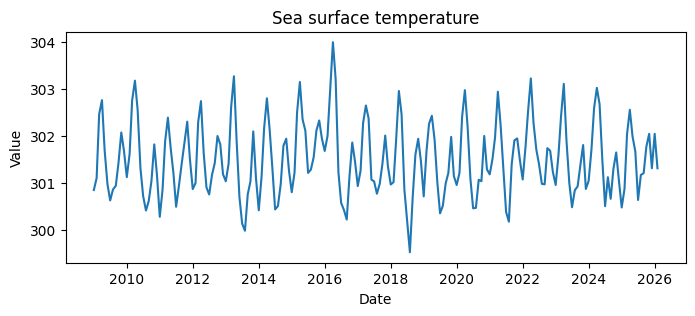

In [1383]:
plt.figure(figsize=(8, 3))
plt.plot(merged_df["Date"], merged_df["Sea surface temperature"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Sea surface temperature")
plt.show()

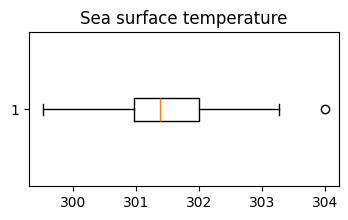

In [1384]:
plt.figure(figsize=(4, 2))
plt.boxplot(merged_df["Sea surface temperature"].dropna(), vert=False)
plt.title("Sea surface temperature")
plt.show()

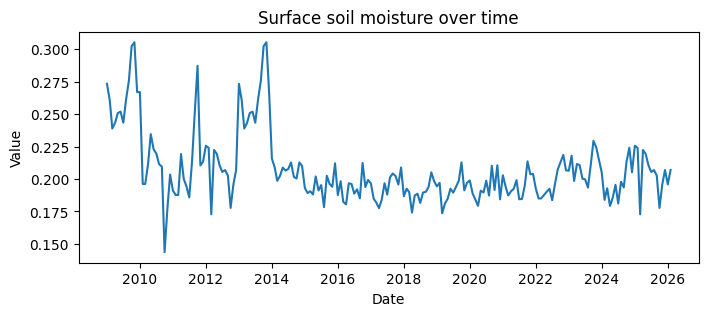

In [1385]:
plt.figure(figsize=(8, 3))
plt.plot(merged_df["Date"], merged_df["Surface soil moisture"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Surface soil moisture over time")
plt.show()

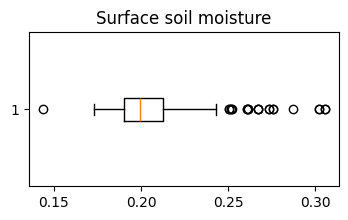

In [1386]:
plt.figure(figsize=(4, 2))
plt.boxplot(merged_df["Surface soil moisture"].dropna(), vert=False)
plt.title("Surface soil moisture")
plt.show()

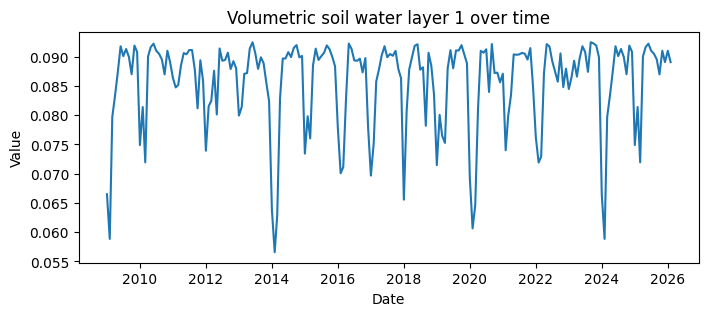

In [1387]:
plt.figure(figsize=(8, 3))
plt.plot(merged_df["Date"], merged_df["Volumetric soil water layer 1"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Volumetric soil water layer 1 over time")
plt.show()

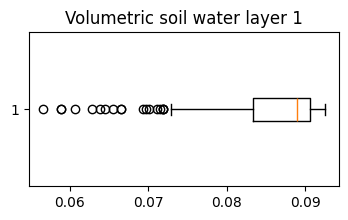

In [1388]:
plt.figure(figsize=(4, 2))
plt.boxplot(merged_df["Volumetric soil water layer 1"].dropna(), vert=False)
plt.title("Volumetric soil water layer 1")
plt.show()

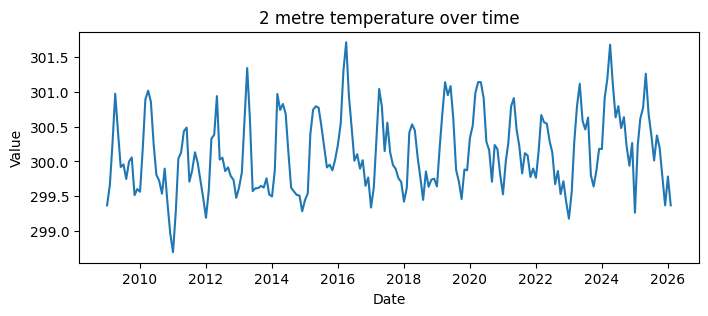

In [1389]:
plt.figure(figsize=(8, 3))
plt.plot(merged_df["Date"], merged_df["2 metre temperature"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("2 metre temperature over time")
plt.show()

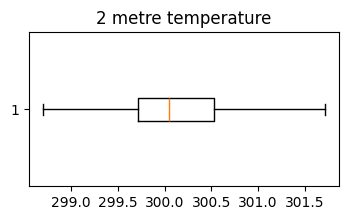

In [1390]:
plt.figure(figsize=(4, 2))
plt.boxplot(merged_df["2 metre temperature"].dropna(), vert=False)
plt.title("2 metre temperature")
plt.show()

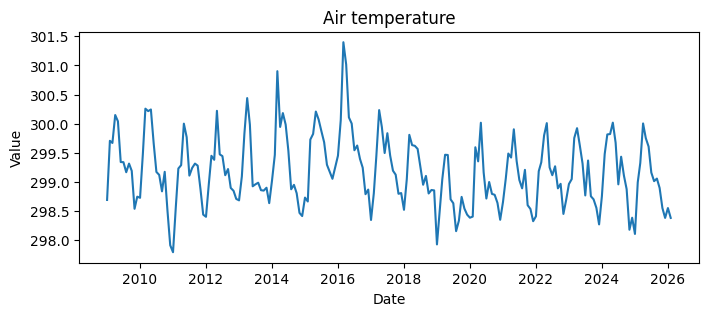

In [1391]:
plt.figure(figsize=(8, 3))
plt.plot(merged_df["Date"], merged_df["Air temperature"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Air temperature")
plt.show()

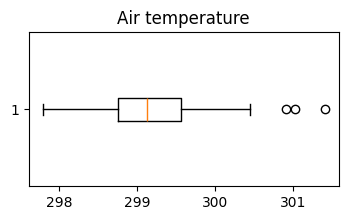

In [1392]:
plt.figure(figsize=(4, 2))
plt.boxplot(merged_df["Air temperature"].dropna(), vert=False)
plt.title("Air temperature")
plt.show()

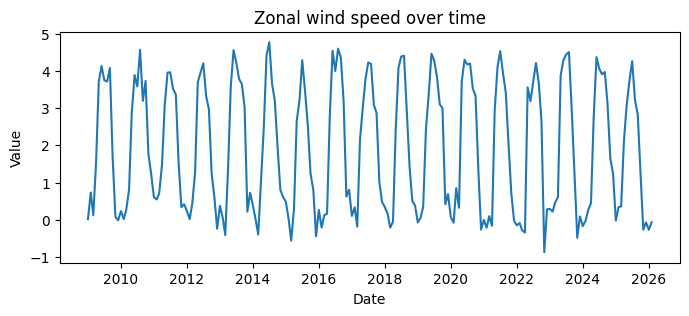

In [1393]:
plt.figure(figsize=(8, 3))
plt.plot(merged_df["Date"], merged_df["Zonal wind speed"])
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Zonal wind speed over time")
plt.show()

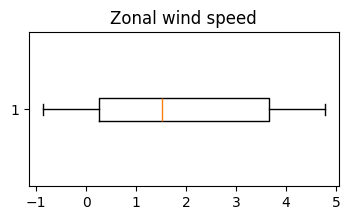

In [1394]:
plt.figure(figsize=(4, 2))
plt.boxplot(merged_df["Zonal wind speed"].dropna(), vert=False)
plt.title("Zonal wind speed")
plt.show()

temporal scale mismatch

# run - pre process events

In [1395]:
raw_df = pd.read_excel('research-dataset/events.xlsx')
print(raw_df)

                  Period      Label
0   4/1/2010 - 3/31/2011  accretion
1   4/1/2011 - 3/31/2012  accretion
2   4/1/2012 - 3/31/2013    erosion
3   4/1/2013 - 3/31/2014    erosion
4   4/1/2014 - 3/31/2015  accretion
5   4/1/2015 - 3/31/2016    erosion
6   4/1/2016 - 3/31/2017  accretion
7   4/1/2017 - 3/31/2018  accretion
8   4/1/2018 - 3/31/2019    erosion
9   4/1/2019 - 3/31/2020    erosion
10  4/1/2020 - 3/31/2021  accretion
11  4/1/2021 - 3/31/2022  accretion
12  4/1/2022 - 3/31/2023    erosion
13  4/1/2023 - 3/31/2024    erosion
14  4/1/2024 - 3/31/2025    erosion


In [1396]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Period  15 non-null     object
 1   Label   15 non-null     object
dtypes: object(2)
memory usage: 372.0+ bytes


# run - hmm model and detect thresholds (env variables + events)

In [1397]:
raw_df[['start_date', 'end_date']] = raw_df['Period'].str.split(' - ', expand=True)

raw_df['start_date'] = pd.to_datetime(raw_df['start_date'])
raw_df['end_date'] = pd.to_datetime(raw_df['end_date'])

data = raw_df.sort_values('start_date').reset_index(drop=True)

data.head()

,Period,Label,start_date,end_date
0,4/1/2010 - 3/31/2011,accretion,2010-04-01,2011-03-31
1,4/1/2011 - 3/31/2012,accretion,2011-04-01,2012-03-31
2,4/1/2012 - 3/31/2013,erosion,2012-04-01,2013-03-31
3,4/1/2013 - 3/31/2014,erosion,2013-04-01,2014-03-31
4,4/1/2014 - 3/31/2015,accretion,2014-04-01,2015-03-31


In [1398]:
merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df = merged_df.sort_values('Date').reset_index(drop=True)

raw_df['start_date'] = pd.to_datetime(raw_df['start_date'])
raw_df['end_date'] = pd.to_datetime(raw_df['end_date'])

In [1399]:
feature_cols = merged_df.columns.drop('Date')

cycle_sequences = []
cycle_labels = []
cycle_years = []

for _, row in raw_df.iterrows():
    mask = (
        (merged_df['Date'] >= row['start_date']) &
        (merged_df['Date'] <= row['end_date'])
    )
    cycle_data = merged_df.loc[mask, feature_cols]

    if len(cycle_data) == 12:
        cycle_sequences.append(cycle_data.values)
        cycle_labels.append(row['Label'])
        cycle_years.append(row['start_date'].year)

In [1400]:
print("Number of extracted cycles:", len(cycle_sequences))

cycle_lengths = [len(seq) for seq in cycle_sequences]
print("Cycle lengths:", cycle_lengths)

print("Unique cycle lengths:", set(cycle_lengths))

print("Label distribution:")
pd.Series(cycle_labels).value_counts()

Number of extracted cycles: 15
Cycle lengths: [12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12]
Unique cycle lengths: {12}
Label distribution:


erosion      8
accretion    7
Name: count, dtype: int64

In [1401]:
scaler = StandardScaler()

X_concat = np.vstack(cycle_sequences)
X_scaled = scaler.fit_transform(X_concat)

lengths = [12] * len(cycle_sequences)

In [1402]:
pd.DataFrame(X_concat).describe().T

,count,mean,std,min,25%,50%,75%,max
0,180.0,-1.913734e-01,4.681242e-01,-1.283917e+00,-5.423286e-01,-1.163508e-01,1.804223e-01,7.986807e-01
1,180.0,9.140944e-08,4.082767e-08,1.450000e-08,6.465000e-08,8.795000e-08,1.150000e-07,2.530000e-07
2,180.0,8.317655e+01,2.327945e+00,7.636336e+01,8.155965e+01,8.373842e+01,8.499305e+01,8.719093e+01
3,180.0,3.014893e+02,7.873799e-01,2.995190e+02,3.009627e+02,3.013540e+02,3.019915e+02,3.039885e+02
4,180.0,2.032215e-01,2.300185e-02,1.436273e-01,1.893991e-01,1.983929e-01,2.107216e-01,3.053039e-01
5,180.0,8.565864e-02,7.522130e-03,5.657974e-02,8.341497e-02,8.851349e-02,9.061823e-02,9.246095e-02
6,180.0,3.001328e+02,5.527298e-01,2.986945e+02,2.997135e+02,3.000576e+02,3.005425e+02,3.017132e+02
7,180.0,2.991789e+02,6.003528e-01,2.977935e+02,2.987766e+02,2.991159e+02,2.995377e+02,3.013993e+02
8,180.0,1.938673e+00,1.732734e+00,-8.710449e-01,3.153225e-01,1.522337e+00,3.660609e+00,4.768369e+00


In [1403]:
hmm = GaussianHMM(
    n_components=4,
    covariance_type='full',
    n_iter=500,
    random_state=42
)

hmm.fit(X_scaled, lengths)

,n_components,4
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,42


In [1404]:
hidden_states = hmm.predict(X_scaled, lengths)

state_sequences = np.split(hidden_states, np.cumsum(lengths)[:-1])

In [1405]:
state_label_map = {}

for state in range(hmm.n_components):
    labels = []
    for seq, lbl in zip(state_sequences, cycle_labels):
        if state in seq:
            labels.append(lbl)
    state_label_map[state] = pd.Series(labels).value_counts(normalize=True)

state_label_map

{0: accretion    0.5
 erosion      0.5
 Name: proportion, dtype: float64,
 1: erosion      0.533333
 accretion    0.466667
 Name: proportion, dtype: float64,
 2: erosion      0.533333
 accretion    0.466667
 Name: proportion, dtype: float64,
 3: erosion      0.538462
 accretion    0.461538
 Name: proportion, dtype: float64}

In [1406]:
erosion_state = max(
    state_label_map,
    key=lambda s: state_label_map[s].get('erosion', 0)
)

print("Erosion-dominant hidden state:", erosion_state)

Erosion-dominant hidden state: 3


In [1407]:
current_start = pd.Timestamp("2025-04-01")

current_mask = merged_df['Date'] >= current_start
current_cycle = merged_df.loc[current_mask, feature_cols]

current_scaled = scaler.transform(current_cycle.values)

current_states = hmm.predict(current_scaled)

print("Observed states so far:", current_states)

Observed states so far: [2 0 0 0 0 0 2 1 3 1 3]


In [1408]:
last_state = current_states[-1]

transition_probs = hmm.transmat_[last_state]

erosion_transition_prob = transition_probs[erosion_state]

print("Probability of entering erosion regime next month:",
      erosion_transition_prob)

Probability of entering erosion regime next month: 0.6391967228843691


In [1409]:
# threshold_scaled = hmm.means_[erosion_state]

# threshold_real = scaler.inverse_transform(
#     threshold_scaled.reshape(1, -1)
# )

# threshold_df = pd.DataFrame(
#     threshold_real,
#     columns=feature_cols,
#     index=["Next_Month_Erosion_Threshold"]
# )

# threshold_df

In [1410]:
# Get all data points belonging to erosion state
erosion_data = X_scaled[hidden_states == erosion_state]

# Use percentile instead of mean
threshold_scaled = np.percentile(erosion_data, 25, axis=0)

In [1411]:
threshold_real = scaler.inverse_transform(
    threshold_scaled.reshape(1, -1)
)

threshold_df = pd.DataFrame(
    threshold_real,
    columns=feature_cols,
    index=["Erosion_Threshold"]
)

In [1412]:
latest_values = current_cycle.iloc[-1]

In [1413]:
comparison = pd.DataFrame({
    'Current_Value': latest_values,
    'Threshold_Value': threshold_df.iloc[0],
})

# Correct interpretation: Current - Threshold
comparison['Gap'] = comparison['Current_Value'] - comparison['Threshold_Value']

comparison = comparison.sort_values('Gap', ascending=False)

comparison

,Current_Value,Threshold_Value,Gap
Sea surface temperature,3.013060e+02,3.009275e+02,3.784200e-01
Volumetric soil water layer 1,8.905468e-02,6.936047e-02,1.969421e-02
Surface soil moisture,2.069449e-01,1.891936e-01,1.775120e-02
Zonal wind speed,-6.690580e-02,-8.441929e-02,1.751349e-02
Precipitation rate,9.800000e-08,3.560000e-08,6.240000e-08
Air temperature,2.983825e+02,2.984106e+02,-2.814000e-02
Meridional wind speed,-3.291529e-02,4.443761e-02,-7.735290e-02
2 metre temperature,2.993681e+02,2.995416e+02,-1.735300e-01
Relative humidity,7.696443e+01,7.870832e+01,-1.743890e+00


In [1414]:
# latest_values = current_cycle.iloc[-1]

# comparison = pd.DataFrame({
#     'Current_Value': latest_values,
#     'Threshold_Value': threshold_df.iloc[0],
#     'Gap': threshold_df.iloc[0] - latest_values
# })

# comparison

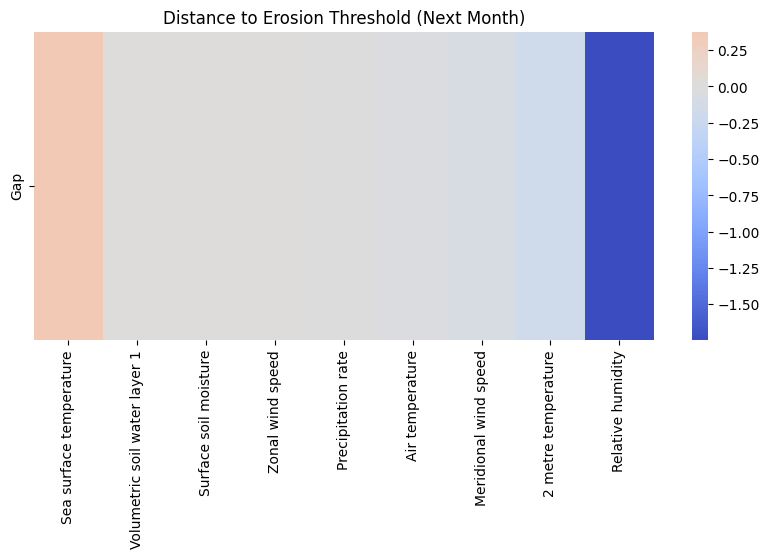

In [1415]:
plt.figure(figsize=(10,4))
sns.heatmap(comparison[['Gap']].T, cmap='coolwarm', center=0)
plt.title("Distance to Erosion Threshold (Next Month)")
plt.show()

Regime stability check

In [1416]:
switch_counts = []

for seq in state_sequences:
    switches = np.sum(seq[1:] != seq[:-1])
    switch_counts.append(switches)

pd.Series(switch_counts).describe()

count    15.000000
mean      4.533333
std       1.125463
min       2.000000
25%       4.000000
50%       5.000000
75%       5.000000
max       6.000000
dtype: float64

Transition matrix sanity

In [1417]:
pd.DataFrame(
    hmm.transmat_,
    columns=[f"S{i}" for i in range(hmm.n_components)],
    index=[f"S{i}" for i in range(hmm.n_components)]
)

,S0,S1,S2,S3
S0,7.557389e-01,8.775063e-14,0.244261,0.000000
S1,1.388819e-320,6.159183e-01,0.029681,0.354401
S2,3.359526e-01,3.356130e-01,0.306017,0.022418
S3,0.000000e+00,1.110357e-01,0.249768,0.639197


Shuffle test

In [1418]:
X_shuffled = X_scaled.copy()
np.random.shuffle(X_shuffled)

hmm_shuffled = GaussianHMM(
    n_components=4,
    covariance_type="full",
    n_iter=300,
    random_state=42
)

hmm_shuffled.fit(X_shuffled, lengths)

,n_components,4
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,42


Regime-wise variable profiles

In [1419]:
state_means = pd.DataFrame(
    hmm.means_,
    columns=feature_cols,
    index=[f"State_{i}" for i in range(hmm.n_components)]
)

state_means

,Meridional wind speed,Precipitation rate,Relative humidity,Sea surface temperature,Surface soil moisture,Volumetric soil water layer 1,2 metre temperature,Air temperature,Zonal wind speed
State_0,-0.342582,0.168437,0.786375,-0.515719,-0.267961,0.636359,0.246583,0.277373,1.060181
State_1,-0.290801,0.234729,-0.273946,0.187442,0.284869,0.192584,-0.760500,-0.716725,-0.870154
State_2,0.262301,0.201821,0.062231,0.648340,0.204424,0.000422,0.469193,0.415415,0.006041
State_3,0.653532,-1.025304,-1.412795,-0.295599,-0.170708,-1.607904,-0.334108,-0.363257,-1.099957


Seasonal alignment test

In [1420]:
state_months = []

for year, seq in zip(cycle_years, state_sequences):
    months = pd.date_range(
        start=f"{year}-04-01", periods=12, freq="MS"
    ).month
    state_months.extend(zip(months, seq))

state_month_df = pd.DataFrame(state_months, columns=["Month", "State"])
pd.crosstab(state_month_df["Month"], state_month_df["State"])

State,0,1,2,3
Month,,,,
1,0,3,0,12
2,0,3,0,12
3,0,5,6,4
4,0,0,15,0
5,10,0,5,0
6,14,0,1,0
7,14,0,1,0
8,12,0,3,0
9,11,0,4,0


Final-state dominance test

In [1421]:
final_states = [
    seq[-1] for seq, lbl in zip(state_sequences, cycle_labels)
    if lbl == "erosion"
]

pd.Series(final_states).value_counts(normalize=True)

2    0.625
1    0.250
3    0.125
Name: proportion, dtype: float64

# run - data validation

In [1422]:
raw_df[['start_date', 'end_date']] = raw_df['Period'].str.split(' - ', expand=True)

raw_df['start_date'] = pd.to_datetime(raw_df['start_date'])
raw_df['end_date'] = pd.to_datetime(raw_df['end_date'])

merged_df['Date'] = pd.to_datetime(merged_df['Date'])

merged_df = merged_df.sort_values('Date').reset_index(drop=True)
raw_df = raw_df.sort_values('start_date').reset_index(drop=True)

In [1423]:
train_end = pd.Timestamp("2024-03-31")

train_raw = raw_df[raw_df['end_date'] <= train_end].copy()
train_env = merged_df[merged_df['Date'] <= train_end].copy()

In [1424]:
feature_cols = train_env.columns.drop('Date')

cycle_sequences = []
cycle_labels = []

for _, row in train_raw.iterrows():
    mask = (
        (train_env['Date'] >= row['start_date']) &
        (train_env['Date'] <= row['end_date'])
    )
    cycle_data = train_env.loc[mask, feature_cols]

    if len(cycle_data) == 12:
        cycle_sequences.append(cycle_data.values)
        cycle_labels.append(row['Label'])

In [1425]:
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM
import numpy as np
import pandas as pd

scaler = StandardScaler()

X_concat = np.vstack(cycle_sequences)
X_scaled = scaler.fit_transform(X_concat)

lengths = [12] * len(cycle_sequences)

hmm = GaussianHMM(
    n_components=4,
    covariance_type='full',
    n_iter=500,
    random_state=42
)

hmm.fit(X_scaled, lengths)

,n_components,4
,covariance_type,'full'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,42


In [1426]:
hidden_states = hmm.predict(X_scaled, lengths)

state_sequences = np.split(hidden_states, np.cumsum(lengths)[:-1])

state_label_map = {}

for state in range(hmm.n_components):
    labels = []
    for seq, lbl in zip(state_sequences, cycle_labels):
        if state in seq:
            labels.append(lbl)
    state_label_map[state] = pd.Series(labels).value_counts(normalize=True)

erosion_state = max(
    state_label_map,
    key=lambda s: state_label_map[s].get('erosion', 0)
)

print("Erosion-dominant state:", erosion_state)

Erosion-dominant state: 3


In [1427]:
# Get all data points belonging to erosion state
erosion_data = X_scaled[hidden_states == erosion_state]

# Choose percentile
percentile_value = 5

threshold_scaled_base = np.percentile(erosion_data, percentile_value, axis=0)

In [1428]:
results = []

start_month = pd.Timestamp("2024-03-01")  # one step before
end_month = pd.Timestamp("2025-03-01")

current_month = start_month

while current_month < end_month:

    next_month = current_month + pd.DateOffset(months=1)

    if next_month > end_month:
        break

    # data up to current month
    current_data = merged_df[merged_df['Date'] <= current_month]

    current_scaled = scaler.transform(current_data[feature_cols].values)

    current_states = hmm.predict(current_scaled)

    last_state = current_states[-1]

    # Transition probabilities
    transition_probs = hmm.transmat_[last_state]

    erosion_prob = transition_probs[erosion_state]

    # Dynamic threshold using percentile base + transition weighting
    threshold_scaled = np.dot(transition_probs, hmm.means_)

    # Blend with percentile baseline
    threshold_scaled = 0.5 * threshold_scaled + 0.5 * threshold_scaled_base

    threshold_real = scaler.inverse_transform(
        threshold_scaled.reshape(1, -1)
    )[0]

    # Get actual next month data
    actual_row = merged_df[merged_df['Date'] == next_month]

    if len(actual_row) == 0:
        break

    actual_values = actual_row[feature_cols].iloc[0]

    gap = threshold_real - actual_values.values

    results.append({
        "Month": next_month,
        "Erosion_Prob": erosion_prob,
        **{f"{col}_threshold": val for col, val in zip(feature_cols, threshold_real)},
        **{f"{col}_actual": val for col, val in zip(feature_cols, actual_values)},
        **{f"{col}_gap": val for col, val in zip(feature_cols, gap)}
    })

    current_month = next_month

In [1429]:
results_df = pd.DataFrame(results)
results_df

,Month,Erosion_Prob,Meridional wind speed_threshold,Precipitation rate_threshold,Relative humidity_threshold,Sea surface temperature_threshold,Surface soil moisture_threshold,Volumetric soil water layer 1_threshold,2 metre temperature_threshold,Air temperature_threshold,...,Zonal wind speed_actual,Meridional wind speed_gap,Precipitation rate_gap,Relative humidity_gap,Sea surface temperature_gap,Surface soil moisture_gap,Volumetric soil water layer 1_gap,2 metre temperature_gap,Air temperature_gap,Zonal wind speed_gap
0,2024-04-01,3.379709e-02,-0.410317,5.413095e-08,81.257368,301.132631,0.191580,0.080559,300.223125,298.936051,...,0.448741,-0.735914,-2.266905e-08,-1.266782,-1.883849,0.012340,-0.002842,-1.455035,-0.886919,1.160968
1,2024-05-01,3.379709e-02,-0.410317,5.413095e-08,81.257368,301.132631,0.191580,0.080559,300.223125,298.936051,...,2.762647,-0.990861,-5.086905e-08,-5.085712,-1.536899,0.006110,-0.006793,-0.886925,-1.082629,-1.152938
2,2024-06-01,3.379709e-02,-0.410317,5.413095e-08,81.257368,301.132631,0.191580,0.080559,300.223125,298.936051,...,4.367859,-0.139339,-6.086905e-08,-4.908892,-0.332729,-0.003938,-0.011215,-0.410515,-0.737079,-2.758150
3,2024-07-01,5.028103e-01,-0.590725,7.517552e-08,83.355740,301.078633,0.192923,0.087192,300.415250,299.128643,...,4.060747,-0.281332,-2.582448e-08,-1.004310,0.580833,0.011777,-0.002893,-0.379180,0.169693,-0.873824
4,2024-08-01,9.657701e-02,-0.576239,7.991434e-08,83.280117,301.092528,0.195684,0.086985,300.263346,299.022206,...,3.907463,0.210675,1.681434e-08,-0.301433,-0.022272,-0.002207,-0.004320,-0.215654,-0.411114,-1.071581
5,2024-09-01,9.657701e-02,-0.576239,7.991434e-08,83.280117,301.092528,0.195684,0.086985,300.263346,299.022206,...,3.969910,-0.337530,-2.408566e-08,-0.767123,0.436978,0.002194,-0.002959,-0.373004,-0.086714,-1.134028
6,2024-10-01,9.657701e-02,-0.576239,7.991434e-08,83.280117,301.092528,0.195684,0.086985,300.263346,299.022206,...,3.119302,0.092702,-3.408566e-08,-1.397123,-0.198002,-0.017583,-0.000007,0.050086,0.145986,-0.283419
7,2024-11-01,9.657701e-02,-0.576239,7.991434e-08,83.280117,301.092528,0.195684,0.086985,300.263346,299.022206,...,1.643106,0.667154,-1.040857e-07,-0.697503,-0.549902,-0.028417,-0.004902,0.324386,0.842486,1.192776
8,2024-12-01,1.855733e-35,-0.568954,7.825974e-08,82.505361,301.111061,0.199582,0.084949,300.088992,298.838421,...,1.247214,0.285407,4.105974e-08,1.447381,0.064561,-0.005627,-0.005857,-0.175168,0.452401,0.828951
9,2025-01-01,1.855733e-35,-0.568954,7.825974e-08,82.505361,301.111061,0.199582,0.084949,300.088992,298.838421,...,-0.021993,-0.718048,-1.714026e-08,-1.502729,0.639231,-0.026024,0.010058,0.826632,0.731021,2.098158


In [1430]:
# Pass ratio (how many variables satisfy threshold)
results_df["Pass_Ratio"] = (results_df.filter(like="_gap") <= 0).mean(axis=1)

# Strict (your original idea)
results_df["Strict_Pass"] = (results_df.filter(like="_gap") <= 0).all(axis=1)

In [1431]:
results_df["Condition_Score"] = (results_df.filter(like="_gap") <= 0).mean(axis=1)

In [1432]:
results_df["Pass_Ratio"] = (results_df.filter(like="_gap") <= 0).mean(axis=1)

<Axes: >

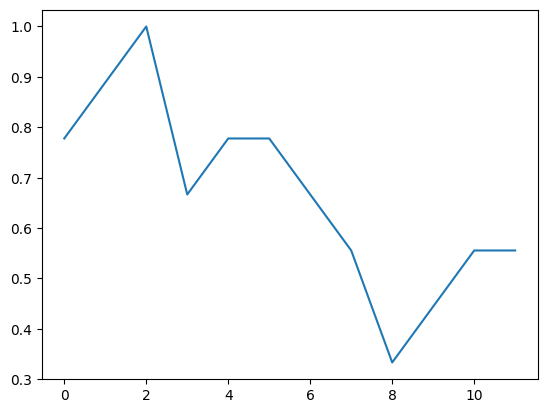

In [1433]:
results_df["Pass_Ratio"].plot()

In [1434]:
results_df["Erosion_Signal"] = results_df["Pass_Ratio"] >= 0.6

In [1435]:
gap_df = results_df.filter(like="_gap")

# count how many times each variable fails
failure_counts = (gap_df > 0).sum()

# identify worst 2 variables
worst_vars = failure_counts.sort_values(ascending=False).head(2).index

# remove them
filtered_cols = [c for c in gap_df.columns if c not in worst_vars]

# recompute score
results_df["Adjusted_Score"] = (gap_df[filtered_cols] <= 0).mean(axis=1)

In [1436]:
results_df.to_csv("erosion_threshold_validation.csv", index=False)

# run - build cvi using evaluation, check cvi for present

In [1437]:
pd.set_option("display.expand_frame_repr", False)

df = pd.read_excel('research-dataset/evaluation.xlsx')

main_df = df[[
    "Date",
    "Elevation Min m",
    "Elevation Max m",
    "Elevation AVG m",
    "Distance meters",
    "Elevation Gain m",
    "Elevation Loss m",
    "AVG Slope steepest upward (%)",
    "AVG Slope steepest downward (%)"
]].copy()

main_df.head()

,Date,Elevation Min m,Elevation Max m,Elevation AVG m,Distance meters,Elevation Gain m,Elevation Loss m,AVG Slope steepest upward (%),AVG Slope steepest downward (%)
0,2025-07-30,0.0,14.63,6.40,1351.85,65.23,-55.17,8.0,-6.7
1,2025-02-28,0.0,14.33,6.40,1367.94,64.92,-54.25,7.5,-6.9
2,2024-02-29,0.0,21.03,4.57,1367.94,61.57,-49.68,7.1,-6.2
3,2023-04-30,0.3,11.89,5.79,1367.94,68.28,-56.99,7.8,-7.2
4,2023-02-28,0.0,15.85,6.10,1367.94,71.93,-60.35,8.9,-7.9


In [1438]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Date                             32 non-null     datetime64[ns]
 1   Elevation Min m                  32 non-null     float64       
 2   Elevation Max m                  32 non-null     float64       
 3   Elevation AVG m                  32 non-null     float64       
 4   Distance meters                  32 non-null     float64       
 5   Elevation Gain m                 32 non-null     float64       
 6   Elevation Loss m                 32 non-null     float64       
 7   AVG Slope steepest upward (%)    32 non-null     float64       
 8   AVG Slope steepest downward (%)  32 non-null     float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 2.4 KB


In [1439]:
main_df.drop(columns=["Date"]).describe()

,Elevation Min m,Elevation Max m,Elevation AVG m,Distance meters,Elevation Gain m,Elevation Loss m,AVG Slope steepest upward (%),AVG Slope steepest downward (%)
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,0.009375,13.554375,5.410937,1364.923750,65.169375,-54.177500,7.665625,-6.950000
std,0.053033,1.986628,1.021398,8.610564,4.690690,4.862977,0.690306,0.622689
min,0.000000,11.580000,3.050000,1351.850000,55.470000,-61.260000,6.400000,-8.000000
25%,0.000000,11.812500,4.570000,1363.917500,62.560000,-57.837500,7.175000,-7.325000
50%,0.000000,13.410000,5.790000,1367.940000,65.075000,-54.555000,7.650000,-6.950000
75%,0.000000,14.330000,6.175000,1367.940000,68.655000,-51.590000,8.200000,-6.500000
max,0.300000,21.030000,7.010000,1384.040000,72.240000,-43.590000,8.900000,-5.500000


In [1440]:
main_df = main_df.copy()

main_df.loc[:, 'Date'] = pd.to_datetime(main_df['Date'])
main_df.loc[:, 'Year'] = main_df['Date'].dt.year

annual_df = (
    main_df.groupby('Year')
    .agg({
        'Elevation Min m': 'mean',
        'Elevation Max m': 'mean',
        'Elevation AVG m': 'mean',
        'Distance meters': 'mean',
        'Elevation Gain m': 'mean',
        'Elevation Loss m': 'mean',
        'AVG Slope steepest upward (%)': 'mean',
        'AVG Slope steepest downward (%)': 'mean'
    })
    .reset_index()
)

annual_df

,Year,Elevation Min m,Elevation Max m,Elevation AVG m,Distance meters,Elevation Gain m,Elevation Loss m,AVG Slope steepest upward (%),AVG Slope steepest downward (%)
0,2010,0.00,14.6300,6.022500,1355.8725,67.5875,-57.835000,8.200000,-7.475000
1,2012,0.00,13.8700,6.400000,1359.8950,64.4650,-54.100000,7.200000,-7.000000
2,2013,0.00,14.3300,6.710000,1367.9400,62.7900,-51.820000,7.100000,-6.500000
3,2014,0.00,13.4100,6.100000,1367.9400,64.9200,-53.640000,7.500000,-6.700000
4,2015,0.00,11.7350,4.115000,1367.9400,57.4550,-46.025000,6.550000,-6.150000
5,2016,0.00,11.5800,3.660000,1367.9400,61.5700,-49.990000,7.600000,-6.400000
6,2017,0.00,12.0900,4.573333,1367.9400,64.7200,-53.443333,7.533333,-6.866667
7,2018,0.00,11.5800,4.570000,1351.8500,72.2400,-60.960000,8.700000,-7.800000
8,2019,0.00,12.7400,5.242000,1371.1600,65.7740,-54.314000,7.640000,-6.980000
9,2020,0.00,12.8775,4.877500,1371.9650,62.4825,-50.672500,7.325000,-6.500000


In [1441]:
df = annual_df.copy()

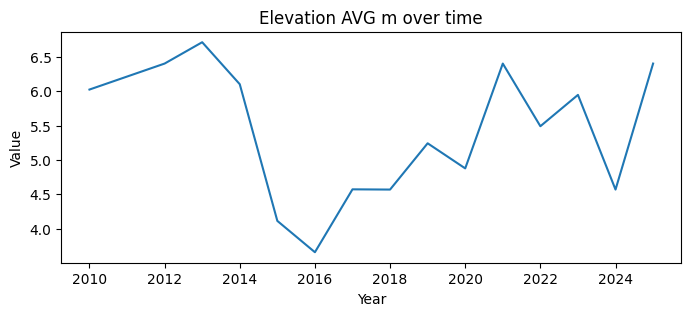

In [1442]:
plt.figure(figsize=(8, 3))
plt.plot(df["Year"], df["Elevation AVG m"])
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Elevation AVG m over time")
plt.show()

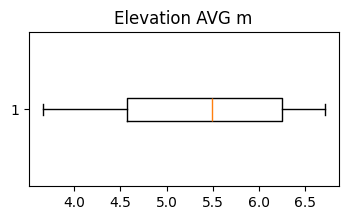

In [1443]:
plt.figure(figsize=(4, 2))
plt.boxplot(df["Elevation AVG m"].dropna(), vert=False)
plt.title("Elevation AVG m")
plt.show()

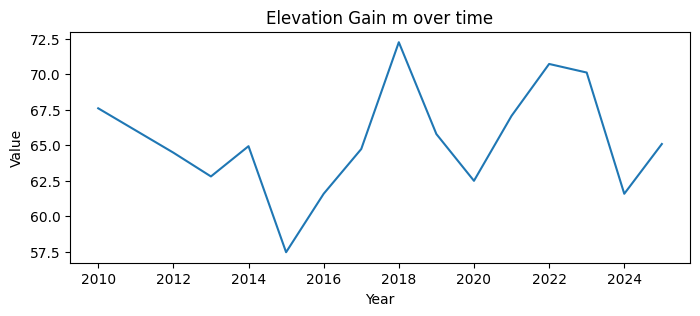

In [1444]:
plt.figure(figsize=(8, 3))
plt.plot(df["Year"], df["Elevation Gain m"])
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Elevation Gain m over time")
plt.show()

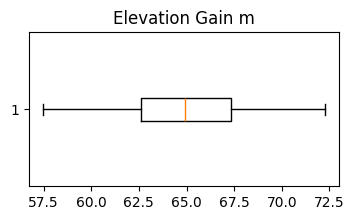

In [1445]:
plt.figure(figsize=(4, 2))
plt.boxplot(df["Elevation Gain m"].dropna(), vert=False)
plt.title("Elevation Gain m")
plt.show()

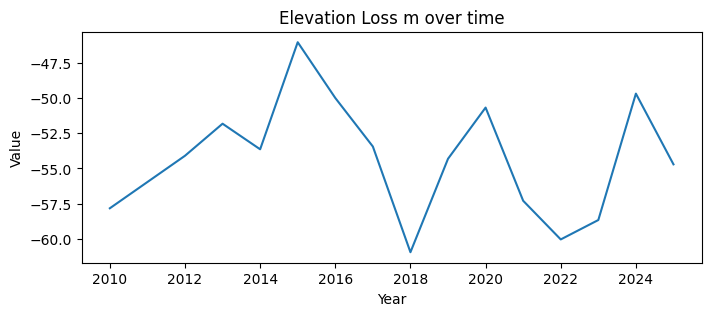

In [1446]:
plt.figure(figsize=(8, 3))
plt.plot(df["Year"], df["Elevation Loss m"])
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Elevation Loss m over time")
plt.show()

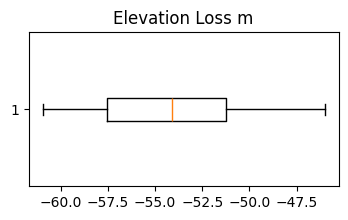

In [1447]:
plt.figure(figsize=(4, 2))
plt.boxplot(df["Elevation Loss m"].dropna(), vert=False)
plt.title("Elevation Loss m")
plt.show()

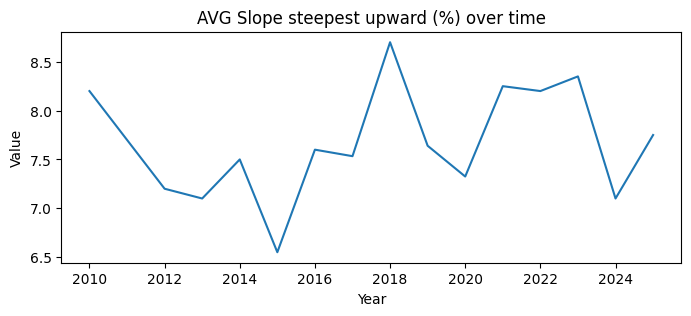

In [1448]:
plt.figure(figsize=(8, 3))
plt.plot(df["Year"], df["AVG Slope steepest upward (%)"])
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("AVG Slope steepest upward (%) over time")
plt.show()

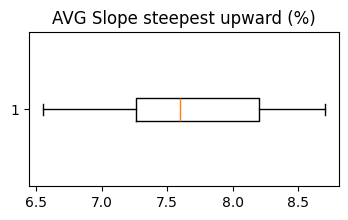

In [1449]:
plt.figure(figsize=(4, 2))
plt.boxplot(df["AVG Slope steepest upward (%)"].dropna(), vert=False)
plt.title("AVG Slope steepest upward (%)")
plt.show()

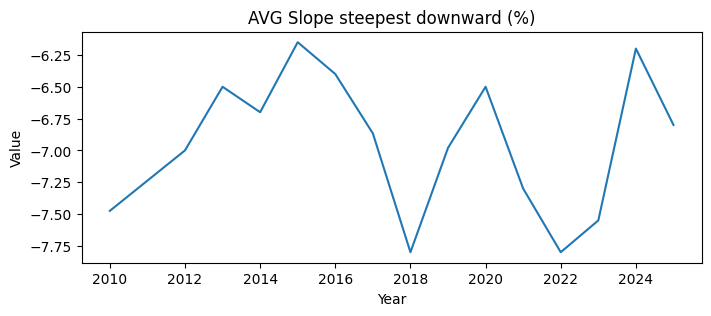

In [1450]:
plt.figure(figsize=(8, 3))
plt.plot(df["Year"], df["AVG Slope steepest downward (%)"])
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("AVG Slope steepest downward (%)")
plt.show()

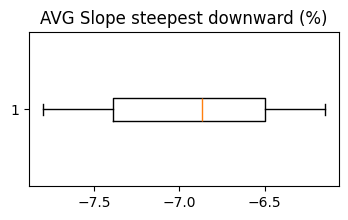

In [1451]:
plt.figure(figsize=(4, 2))
plt.boxplot(df["AVG Slope steepest downward (%)"].dropna(), vert=False)
plt.title("AVG Slope steepest downward (%)")
plt.show()

In [1452]:
df["Elevation AVG m"].quantile([0, 0.25, 0.5, 0.75, 1.0])

0.00    3.660000
0.25    4.571667
0.50    5.490000
0.75    6.250000
1.00    6.710000
Name: Elevation AVG m, dtype: float64

In [1453]:
elev_avg = df["Elevation AVG m"].quantile([0, 0.25, 0.5, 0.75, 1])

elev_avg_min = elev_avg.loc[0.0]
elev_avg_max = elev_avg.loc[1.0]

In [1454]:
def Elevation_AVG_m(value, series):
    q25, q50, q75 = series.quantile([0.25, 0.5, 0.75])

    if value <= q25:
        return 4
    elif value <= q50:
        return 3
    elif value <= q75:
        return 2
    else:
        return 1

In [1455]:
df["Elevation Gain m"].quantile([0, 0.25, 0.5, 0.75, 1.0])

0.00    57.45500
0.25    62.63625
0.50    64.92000
0.75    67.32125
1.00    72.24000
Name: Elevation Gain m, dtype: float64

In [1456]:
elev_gain = df["Elevation Gain m"].quantile([0, 0.25, 0.5, 0.75, 1])

elev_gain_min = elev_gain.loc[0.0]
elev_gain_max = elev_gain.loc[1.0]

In [1457]:
def Elevation_Gain_m(value, series):
    q25, q50, q75 = series.quantile([0.25, 0.5, 0.75])

    if value <= q25:
        return 4
    elif value <= q50:
        return 3
    elif value <= q75:
        return 2
    else:
        return 1

In [1458]:
df["Elevation Loss m"].quantile([0, 0.25, 0.5, 0.75, 1.0])

0.00   -60.96000
0.25   -57.56750
0.50   -54.10000
0.75   -51.24625
1.00   -46.02500
Name: Elevation Loss m, dtype: float64

In [1459]:
elev_loss = df["Elevation Loss m"].quantile([0, 0.25, 0.5, 0.75, 1])

elev_loss_min = elev_loss.loc[0.0]
elev_loss_max = elev_loss.loc[1.0]

In [1460]:
def Elevation_Loss_m(value, series):
    q25, q50, q75 = series.quantile([0.25, 0.5, 0.75])

    if value <= q25:
        return 4
    elif value <= q50:
        return 3
    elif value <= q75:
        return 2
    else:
        return 1

In [1461]:
df["AVG Slope steepest upward (%)"].quantile([0, 0.25, 0.5, 0.75, 1.0])

0.00    6.5500
0.25    7.2625
0.50    7.6000
0.75    8.2000
1.00    8.7000
Name: AVG Slope steepest upward (%), dtype: float64

In [1462]:
slope_up = df["AVG Slope steepest upward (%)"].quantile([0, 0.25, 0.5, 0.75, 1])

slope_up_min = slope_up.loc[0.0]
slope_up_max = slope_up.loc[1.0]

In [1463]:
def AVG_Slope_steepest_upward(value, series):
    q25, q50, q75 = series.quantile([0.25, 0.5, 0.75])

    if value <= q25:
        return 4
    elif value <= q50:
        return 3
    elif value <= q75:
        return 2
    else:
        return 1

In [1464]:
df["AVG Slope steepest downward (%)"].quantile([0, 0.25, 0.5, 0.75, 1.0])

0.00   -7.800000
0.25   -7.387500
0.50   -6.866667
0.75   -6.500000
1.00   -6.150000
Name: AVG Slope steepest downward (%), dtype: float64

In [1465]:
slope_down = df["AVG Slope steepest downward (%)"].quantile([0, 0.25, 0.5, 0.75, 1])

slope_down_min = slope_down.loc[0.0]
slope_down_max = slope_down.loc[1.0]

In [1466]:
def AVG_Slope_steepest_downward(value, series):
    q25, q50, q75 = series.quantile([0.25, 0.5, 0.75])

    if value <= q25:
        return 4
    elif value <= q50:
        return 3
    elif value <= q75:
        return 2
    else:
        return 1

In [1467]:
def CVI (value1, value2, value3, value4, value5):
  r_elev_avg  = Elevation_AVG_m(value1, df['Elevation AVG m'])
  r_elev_gain = Elevation_Gain_m(value2, df['Elevation Gain m'])
  r_elev_loss = Elevation_Loss_m(value3, df['Elevation Loss m'])
  r_slope_up = AVG_Slope_steepest_upward(value4, df['AVG Slope steepest upward (%)'])
  r_slope_down = AVG_Slope_steepest_downward(value5, df['AVG Slope steepest downward (%)'])

  ranks = np.array([
        r_elev_avg,
        r_elev_gain,
        r_elev_loss,
        r_slope_up,
        r_slope_down
    ])

  CVI = np.sqrt(ranks.prod() / len(ranks))
  return CVI

In [1468]:
upper_bound = CVI(elev_avg_min,elev_gain_min,elev_loss_min,slope_up_min,slope_down_min)
print(upper_bound)

14.310835055998654


In [1469]:
lower_bound = CVI(elev_avg_max,elev_gain_max,elev_loss_max,slope_up_max,slope_down_max)
print(lower_bound)

0.4472135954999579


In [1470]:
def CVI_VULNERABILITY(value, upper_bound, lower_bound):
    interval = (upper_bound - lower_bound) / 4

    r1 = lower_bound + interval
    r2 = lower_bound + 2 * interval
    r3 = lower_bound + 3 * interval

    if value <= r1:
        return "very low"
    elif value <= r2:
        return "low"
    elif value <= r3:
        return "moderate"
    else:
        return "high"

In [1471]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             15 non-null     int32  
 1   Elevation Min m                  15 non-null     float64
 2   Elevation Max m                  15 non-null     float64
 3   Elevation AVG m                  15 non-null     float64
 4   Distance meters                  15 non-null     float64
 5   Elevation Gain m                 15 non-null     float64
 6   Elevation Loss m                 15 non-null     float64
 7   AVG Slope steepest upward (%)    15 non-null     float64
 8   AVG Slope steepest downward (%)  15 non-null     float64
dtypes: float64(8), int32(1)
memory usage: 1.1 KB


In [1472]:
latest_row = df.loc[df["Year"].idxmax()]
print(latest_row)

Year                               2025.000
Elevation Min m                       0.000
Elevation Max m                      14.480
Elevation AVG m                       6.400
Distance meters                    1359.895
Elevation Gain m                     65.075
Elevation Loss m                    -54.710
AVG Slope steepest upward (%)         7.750
AVG Slope steepest downward (%)      -6.800
Name: 14, dtype: float64


In [1473]:
value1 = latest_row["Elevation AVG m"]
value2 = latest_row["Elevation Gain m"]
value3 = latest_row["Elevation Loss m"]
value4 = latest_row["AVG Slope steepest upward (%)"]
value5 = latest_row["AVG Slope steepest downward (%)"]

CVI_VULNERABILITY(CVI(value1, value2, value3, value4, value5),upper_bound,lower_bound)

'very low'

# run - forecast evaluation, check cvi for forecast

In [1474]:
source_df = annual_df.copy()

cvi_columns = [
    "Year",
    "Elevation AVG m",
    "Elevation Gain m",
    "Elevation Loss m",
    "AVG Slope steepest upward (%)",
    "AVG Slope steepest downward (%)"
]

source_df = source_df[cvi_columns]

In [1475]:
source_df

,Year,Elevation AVG m,Elevation Gain m,Elevation Loss m,AVG Slope steepest upward (%),AVG Slope steepest downward (%)
0,2010,6.022500,67.5875,-57.835000,8.200000,-7.475000
1,2012,6.400000,64.4650,-54.100000,7.200000,-7.000000
2,2013,6.710000,62.7900,-51.820000,7.100000,-6.500000
3,2014,6.100000,64.9200,-53.640000,7.500000,-6.700000
4,2015,4.115000,57.4550,-46.025000,6.550000,-6.150000
5,2016,3.660000,61.5700,-49.990000,7.600000,-6.400000
6,2017,4.573333,64.7200,-53.443333,7.533333,-6.866667
7,2018,4.570000,72.2400,-60.960000,8.700000,-7.800000
8,2019,5.242000,65.7740,-54.314000,7.640000,-6.980000
9,2020,4.877500,62.4825,-50.672500,7.325000,-6.500000


In [1476]:
source_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             15 non-null     int32  
 1   Elevation AVG m                  15 non-null     float64
 2   Elevation Gain m                 15 non-null     float64
 3   Elevation Loss m                 15 non-null     float64
 4   AVG Slope steepest upward (%)    15 non-null     float64
 5   AVG Slope steepest downward (%)  15 non-null     float64
dtypes: float64(5), int32(1)
memory usage: 792.0 bytes


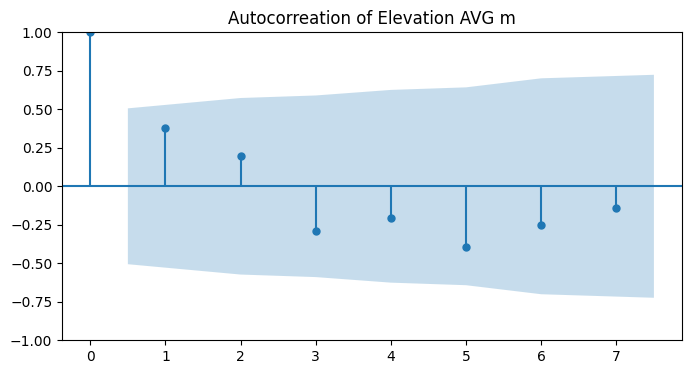

In [1477]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(source_df["Elevation AVG m"], ax=ax)
plt.title("Autocorreation of Elevation AVG m")
plt.show()

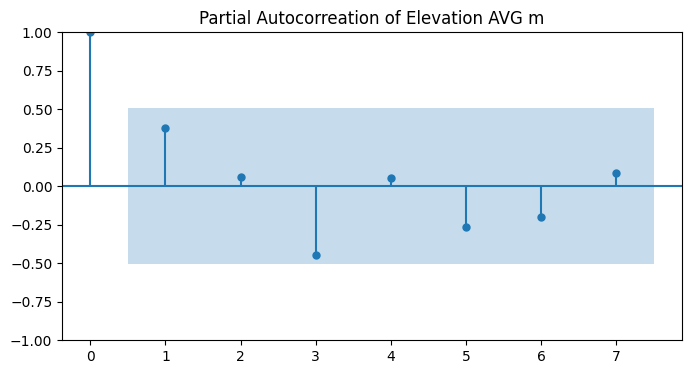

In [1478]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_pacf(source_df["Elevation AVG m"], ax=ax)
plt.title("Partial Autocorreation of Elevation AVG m")
plt.show()

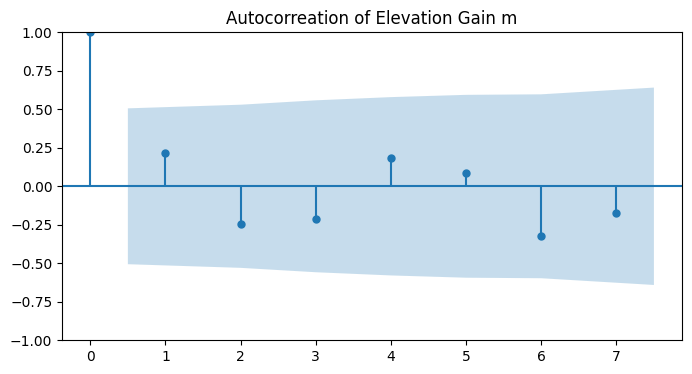

In [1479]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(source_df["Elevation Gain m"], ax=ax)
plt.title("Autocorreation of Elevation Gain m")
plt.show()

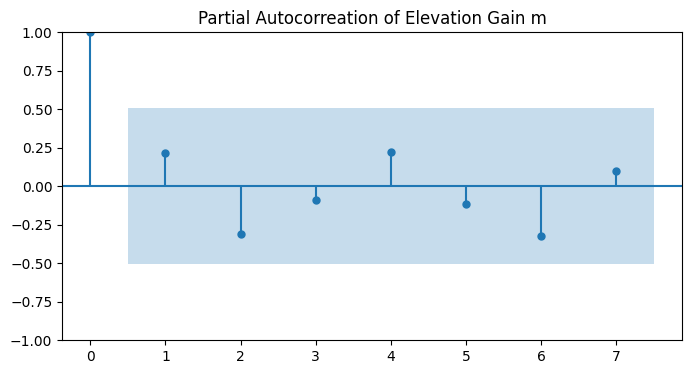

In [1480]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_pacf(source_df["Elevation Gain m"], ax=ax)
plt.title("Partial Autocorreation of Elevation Gain m")
plt.show()

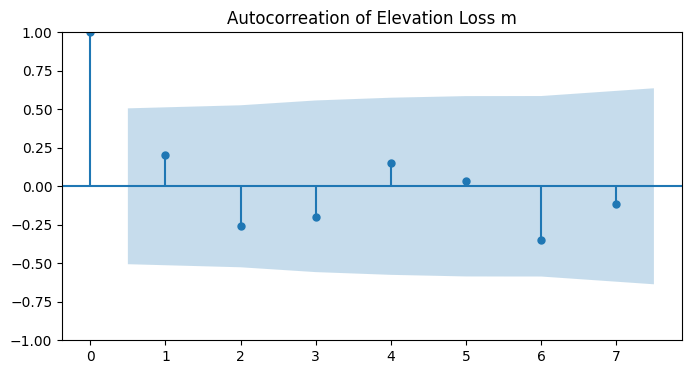

In [1481]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(source_df["Elevation Loss m"], ax=ax)
plt.title("Autocorreation of Elevation Loss m")
plt.show()

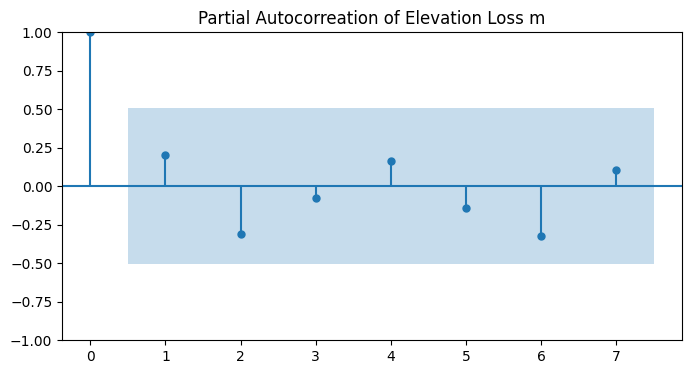

In [1482]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_pacf(source_df["Elevation Loss m"], ax=ax)
plt.title("Partial Autocorreation of Elevation Loss m")
plt.show()

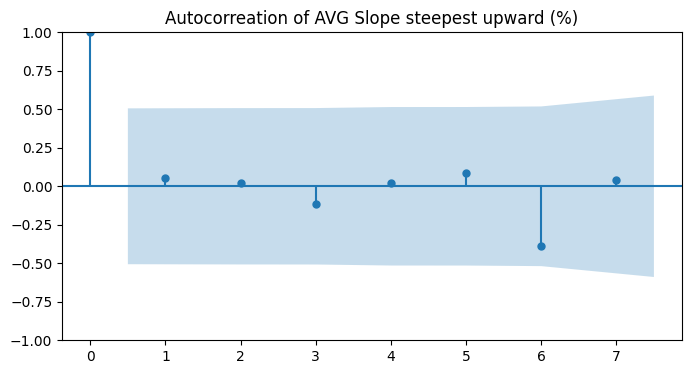

In [1483]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(source_df["AVG Slope steepest upward (%)"], ax=ax)
plt.title("Autocorreation of AVG Slope steepest upward (%)")
plt.show()

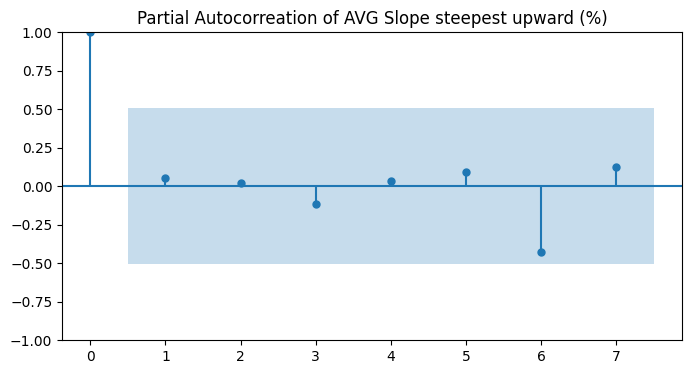

In [1484]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_pacf(source_df["AVG Slope steepest upward (%)"], ax=ax)
plt.title("Partial Autocorreation of AVG Slope steepest upward (%)")
plt.show()

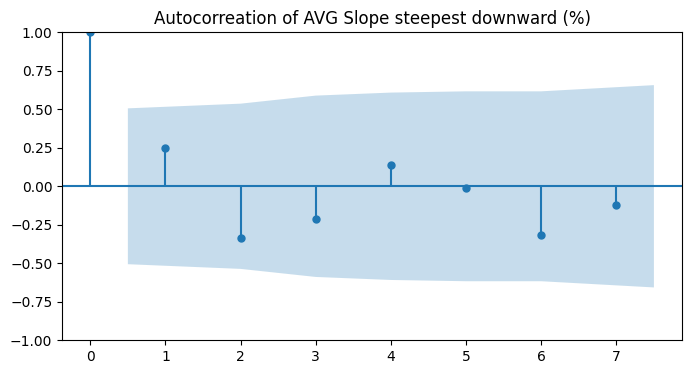

In [1485]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(source_df["AVG Slope steepest downward (%)"], ax=ax)
plt.title("Autocorreation of AVG Slope steepest downward (%)")
plt.show()

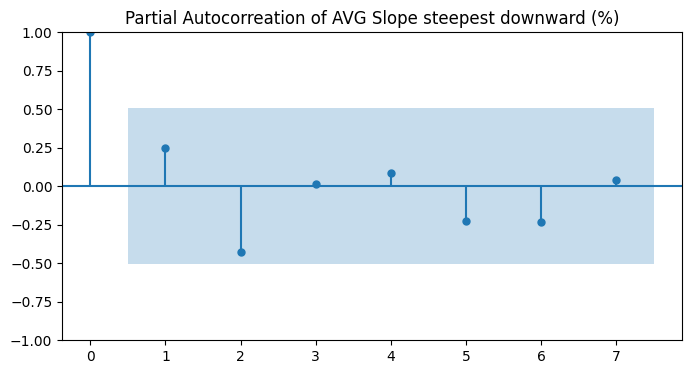

In [1486]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_pacf(source_df["AVG Slope steepest downward (%)"], ax=ax)
plt.title("Partial Autocorreation of AVG Slope steepest downward (%)")
plt.show()

In [1487]:
source_df = source_df.sort_values("Year")
source_df = source_df.set_index("Year")

source_df.index = pd.to_datetime(source_df.index, format="%Y")

In [1488]:
adf_results = []

for col in source_df.select_dtypes(include="number").columns:
    result = adfuller(source_df[col].dropna())

    adf_results.append({
        "Variable": col,
        "ADF Statistic": result[0],
        "p-value": result[1],
        "Lags Used": result[2],
        "Observations": result[3],
        "Stationary (p<0.05)": result[1] < 0.05
    })

adf_df = pd.DataFrame(adf_results)
adf_df

,Variable,ADF Statistic,p-value,Lags Used,Observations,Stationary (p<0.05)
0,Elevation AVG m,-2.537748,0.106558,5,9,False
1,Elevation Gain m,-4.442732,0.000249,5,9,True
2,Elevation Loss m,-3.419009,0.010328,5,9,True
3,AVG Slope steepest upward (%),-4.182456,0.000705,5,9,True
4,AVG Slope steepest downward (%),-2.396770,0.142650,5,9,False


In [1489]:
non_stationary_vars = adf_df.loc[
    adf_df["Stationary (p<0.05)"] == False, "Variable"
].tolist()

non_stationary_vars

['Elevation AVG m', 'AVG Slope steepest downward (%)']

In [1490]:
df_diff = source_df.copy()

for col in non_stationary_vars:
    df_diff[col] = df_diff[col].diff()

In [1491]:
adf_results_stationary = []

for col in df_diff.select_dtypes(include="number").columns:
    result = adfuller(df_diff[col].dropna())

    adf_results_stationary.append({
          "Variable": col,
          "ADF Statistic": result[0],
          "p-value": result[1],
          "Lags Used": result[2],
          "Observations": result[3],
          "Stationary (p<0.05)": result[1] < 0.05
      })

adf_df = pd.DataFrame(adf_results_stationary)
adf_df

,Variable,ADF Statistic,p-value,Lags Used,Observations,Stationary (p<0.05)
0,Elevation AVG m,-1.899556,0.332270,5,8,False
1,Elevation Gain m,-4.442732,0.000249,5,9,True
2,Elevation Loss m,-3.419009,0.010328,5,9,True
3,AVG Slope steepest upward (%),-4.182456,0.000705,5,9,True
4,AVG Slope steepest downward (%),-3.416003,0.010425,2,11,True


Multivariate Linear Trend

In [1492]:
trend_df = source_df.copy()

t = np.arange(len(trend_df))

In [1493]:
trend_forecast = {}

for col in trend_df.columns:
    model = LinearRegression()
    model.fit(t.reshape(-1, 1), trend_df[col].values)
    trend_forecast[col] = model.predict([[len(t)]])[0]

In [1494]:
trend_2026 = pd.DataFrame(trend_forecast, index=[2026])
trend_2026

,Elevation AVG m,Elevation Gain m,Elevation Loss m,AVG Slope steepest upward (%),AVG Slope steepest downward (%)
2026,5.272341,66.847643,-55.572722,7.951032,-7.045873


metric

In [1495]:
trend_errors = []

for i in range(8, len(trend_df) - 1):
    train = trend_df.iloc[:i]
    t_train = np.arange(len(train))

    preds = []
    for col in train.columns:
        lr = LinearRegression()
        lr.fit(t_train.reshape(-1, 1), train[col].values)
        preds.append(lr.predict([[len(train)]])[0])

    true = trend_df.iloc[i].values
    trend_errors.append(mean_squared_error(true, preds))

trend_rmse = np.sqrt(np.mean(trend_errors))
trend_rmse

np.float64(2.854487639210748)

cvi for forecast

In [1496]:
value1 = trend_df["Elevation AVG m"].iloc[0]
value2 = trend_df["Elevation Gain m"].iloc[0]
value3 = trend_df["Elevation Loss m"].iloc[0]
value4 = trend_df["AVG Slope steepest upward (%)"].iloc[0]
value5 = trend_df["AVG Slope steepest downward (%)"].iloc[0]

cvi_level = CVI_VULNERABILITY(CVI(value1, value2, value3, value4, value5),upper_bound,lower_bound)

# run - build bmsi using evaluation, check bmsi for present

In [1497]:
pd.set_option("display.expand_frame_repr", False)

df = pd.read_excel('research-dataset/evaluation.xlsx')

main_df = df[[
    "Date",
    "Elevation Min m",
    "Elevation Max m",
    "Elevation AVG m",
    "Distance meters",
    "Elevation Gain m",
    "Elevation Loss m",
    "AVG Slope steepest upward (%)",
    "AVG Slope steepest downward (%)"
]].copy()

main_df.head()

,Date,Elevation Min m,Elevation Max m,Elevation AVG m,Distance meters,Elevation Gain m,Elevation Loss m,AVG Slope steepest upward (%),AVG Slope steepest downward (%)
0,2025-07-30,0.0,14.63,6.40,1351.85,65.23,-55.17,8.0,-6.7
1,2025-02-28,0.0,14.33,6.40,1367.94,64.92,-54.25,7.5,-6.9
2,2024-02-29,0.0,21.03,4.57,1367.94,61.57,-49.68,7.1,-6.2
3,2023-04-30,0.3,11.89,5.79,1367.94,68.28,-56.99,7.8,-7.2
4,2023-02-28,0.0,15.85,6.10,1367.94,71.93,-60.35,8.9,-7.9


In [1498]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Date                             32 non-null     datetime64[ns]
 1   Elevation Min m                  32 non-null     float64       
 2   Elevation Max m                  32 non-null     float64       
 3   Elevation AVG m                  32 non-null     float64       
 4   Distance meters                  32 non-null     float64       
 5   Elevation Gain m                 32 non-null     float64       
 6   Elevation Loss m                 32 non-null     float64       
 7   AVG Slope steepest upward (%)    32 non-null     float64       
 8   AVG Slope steepest downward (%)  32 non-null     float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 2.4 KB


In [1499]:
main_df.drop(columns=["Date"]).describe()

,Elevation Min m,Elevation Max m,Elevation AVG m,Distance meters,Elevation Gain m,Elevation Loss m,AVG Slope steepest upward (%),AVG Slope steepest downward (%)
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,0.009375,13.554375,5.410937,1364.923750,65.169375,-54.177500,7.665625,-6.950000
std,0.053033,1.986628,1.021398,8.610564,4.690690,4.862977,0.690306,0.622689
min,0.000000,11.580000,3.050000,1351.850000,55.470000,-61.260000,6.400000,-8.000000
25%,0.000000,11.812500,4.570000,1363.917500,62.560000,-57.837500,7.175000,-7.325000
50%,0.000000,13.410000,5.790000,1367.940000,65.075000,-54.555000,7.650000,-6.950000
75%,0.000000,14.330000,6.175000,1367.940000,68.655000,-51.590000,8.200000,-6.500000
max,0.300000,21.030000,7.010000,1384.040000,72.240000,-43.590000,8.900000,-5.500000


In [1500]:
main_df = main_df.copy()

main_df.loc[:, 'Date'] = pd.to_datetime(main_df['Date'])
main_df.loc[:, 'Year'] = main_df['Date'].dt.year

annual_df = (
    main_df.groupby('Year')
    .agg({
        'Elevation Min m': 'mean',
        'Elevation Max m': 'mean',
        'Elevation AVG m': 'mean',
        'Distance meters': 'mean',
        'Elevation Gain m': 'mean',
        'Elevation Loss m': 'mean',
        'AVG Slope steepest upward (%)': 'mean',
        'AVG Slope steepest downward (%)': 'mean'
    })
    .reset_index()
)

annual_df

,Year,Elevation Min m,Elevation Max m,Elevation AVG m,Distance meters,Elevation Gain m,Elevation Loss m,AVG Slope steepest upward (%),AVG Slope steepest downward (%)
0,2010,0.00,14.6300,6.022500,1355.8725,67.5875,-57.835000,8.200000,-7.475000
1,2012,0.00,13.8700,6.400000,1359.8950,64.4650,-54.100000,7.200000,-7.000000
2,2013,0.00,14.3300,6.710000,1367.9400,62.7900,-51.820000,7.100000,-6.500000
3,2014,0.00,13.4100,6.100000,1367.9400,64.9200,-53.640000,7.500000,-6.700000
4,2015,0.00,11.7350,4.115000,1367.9400,57.4550,-46.025000,6.550000,-6.150000
5,2016,0.00,11.5800,3.660000,1367.9400,61.5700,-49.990000,7.600000,-6.400000
6,2017,0.00,12.0900,4.573333,1367.9400,64.7200,-53.443333,7.533333,-6.866667
7,2018,0.00,11.5800,4.570000,1351.8500,72.2400,-60.960000,8.700000,-7.800000
8,2019,0.00,12.7400,5.242000,1371.1600,65.7740,-54.314000,7.640000,-6.980000
9,2020,0.00,12.8775,4.877500,1371.9650,62.4825,-50.672500,7.325000,-6.500000


In [1501]:
df = annual_df.copy()

In [1502]:
df["Elevation AVG m"].quantile([0, 0.25, 0.5, 0.75, 1.0])

0.00    3.660000
0.25    4.571667
0.50    5.490000
0.75    6.250000
1.00    6.710000
Name: Elevation AVG m, dtype: float64

In [1503]:
elev_avg = df["Elevation AVG m"].quantile([0, 0.25, 0.5, 0.75, 1])

elev_avg_min = elev_avg.loc[0.0]
elev_avg_max = elev_avg.loc[1.0]

In [1504]:
def Elevation_AVG_m(value, series):
    q25, q50, q75 = series.quantile([0.25, 0.5, 0.75])

    if value <= q25:
        return 1
    elif value <= q50:
        return 2
    elif value <= q75:
        return 3
    else:
        return 4

In [1505]:
df["Elevation Gain m"].quantile([0, 0.25, 0.5, 0.75, 1.0])

0.00    57.45500
0.25    62.63625
0.50    64.92000
0.75    67.32125
1.00    72.24000
Name: Elevation Gain m, dtype: float64

In [1506]:
elev_gain = df["Elevation Gain m"].quantile([0, 0.25, 0.5, 0.75, 1])

elev_gain_min = elev_gain.loc[0.0]
elev_gain_max = elev_gain.loc[1.0]

In [1507]:
def Elevation_Gain_m(value, series):
    q25, q50, q75 = series.quantile([0.25, 0.5, 0.75])

    if value <= q25:
        return 1
    elif value <= q50:
        return 2
    elif value <= q75:
        return 3
    else:
        return 4

In [1508]:
df["Elevation Loss m"].quantile([0, 0.25, 0.5, 0.75, 1.0])

0.00   -60.96000
0.25   -57.56750
0.50   -54.10000
0.75   -51.24625
1.00   -46.02500
Name: Elevation Loss m, dtype: float64

In [1509]:
elev_loss = df["Elevation Loss m"].quantile([0, 0.25, 0.5, 0.75, 1])

elev_loss_min = elev_loss.loc[0.0]
elev_loss_max = elev_loss.loc[1.0]

In [1510]:
def Elevation_Loss_m(value, series):
    q25, q50, q75 = series.quantile([0.25, 0.5, 0.75])

    if value <= q25:
        return 4
    elif value <= q50:
        return 3
    elif value <= q75:
        return 2
    else:
        return 1

In [1511]:
df["AVG Slope steepest upward (%)"].quantile([0, 0.25, 0.5, 0.75, 1.0])

0.00    6.5500
0.25    7.2625
0.50    7.6000
0.75    8.2000
1.00    8.7000
Name: AVG Slope steepest upward (%), dtype: float64

In [1512]:
slope_up = df["AVG Slope steepest upward (%)"].quantile([0, 0.25, 0.5, 0.75, 1])

slope_up_min = slope_up.loc[0.0]
slope_up_max = slope_up.loc[1.0]

In [1513]:
def AVG_Slope_steepest_upward(value, series):
    q25, q50, q75 = series.quantile([0.25, 0.5, 0.75])

    if value <= q25:
        return 1
    elif value <= q50:
        return 2
    elif value <= q75:
        return 3
    else:
        return 4

In [1514]:
df["AVG Slope steepest downward (%)"].quantile([0, 0.25, 0.5, 0.75, 1.0])

0.00   -7.800000
0.25   -7.387500
0.50   -6.866667
0.75   -6.500000
1.00   -6.150000
Name: AVG Slope steepest downward (%), dtype: float64

In [1515]:
slope_down = df["AVG Slope steepest downward (%)"].quantile([0, 0.25, 0.5, 0.75, 1])

slope_down_min = slope_down.loc[0.0]
slope_down_max = slope_down.loc[1.0]

In [1516]:
def AVG_Slope_steepest_downward(value, series):
    q25, q50, q75 = series.quantile([0.25, 0.5, 0.75])

    if value <= q25:
        return 4
    elif value <= q50:
        return 3
    elif value <= q75:
        return 2
    else:
        return 1

In [1517]:
def BMSI (value1, value2, value3, value4, value5):
  r_elev_avg  = Elevation_AVG_m(value1, df['Elevation AVG m'])
  r_elev_gain = Elevation_Gain_m(value2, df['Elevation Gain m'])
  r_elev_loss = Elevation_Loss_m(value3, df['Elevation Loss m'])
  r_slope_up = AVG_Slope_steepest_upward(value4, df['AVG Slope steepest upward (%)'])
  r_slope_down = AVG_Slope_steepest_downward(value5, df['AVG Slope steepest downward (%)'])

  ranks = np.array([
        r_elev_avg,
        r_elev_gain,
        r_elev_loss,
        r_slope_up,
        r_slope_down
    ])

  BMSI = np.sqrt(ranks.prod() / len(ranks))
  return BMSI

In [1518]:
upper_bound = BMSI(elev_avg_min,elev_gain_min,elev_loss_min,slope_up_min,slope_down_min)
print(upper_bound)

1.7888543819998317


In [1519]:
lower_bound = BMSI(elev_avg_max,elev_gain_max,elev_loss_max,slope_up_max,slope_down_max)
print(lower_bound)

3.5777087639996634


In [1520]:
def BMSI_STABILITY(value, upper_bound, lower_bound):
    interval = (upper_bound - lower_bound) / 4

    r1 = lower_bound + interval
    r2 = lower_bound + 2 * interval
    r3 = lower_bound + 3 * interval

    if value <= r1:
        print("Very low")
    elif value <= r2:
        print("Low")
    elif value <= r3:
        print("Moderate")
    else:
        print("High")

In [1521]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             15 non-null     int32  
 1   Elevation Min m                  15 non-null     float64
 2   Elevation Max m                  15 non-null     float64
 3   Elevation AVG m                  15 non-null     float64
 4   Distance meters                  15 non-null     float64
 5   Elevation Gain m                 15 non-null     float64
 6   Elevation Loss m                 15 non-null     float64
 7   AVG Slope steepest upward (%)    15 non-null     float64
 8   AVG Slope steepest downward (%)  15 non-null     float64
dtypes: float64(8), int32(1)
memory usage: 1.1 KB


In [1522]:
latest_row = df.loc[df["Year"].idxmax()]
print(latest_row)

Year                               2025.000
Elevation Min m                       0.000
Elevation Max m                      14.480
Elevation AVG m                       6.400
Distance meters                    1359.895
Elevation Gain m                     65.075
Elevation Loss m                    -54.710
AVG Slope steepest upward (%)         7.750
AVG Slope steepest downward (%)      -6.800
Name: 14, dtype: float64


In [1523]:
value1 = latest_row["Elevation AVG m"]
value2 = latest_row["Elevation Gain m"]
value3 = latest_row["Elevation Loss m"]
value4 = latest_row["AVG Slope steepest upward (%)"]
value5 = latest_row["AVG Slope steepest downward (%)"]

BMSI_STABILITY(BMSI(value1, value2, value3, value4, value5),upper_bound,lower_bound)

High


# run - forecast evaluation, check bmsi for forecast

In [1524]:
value1 = trend_df["Elevation AVG m"].iloc[0]
value2 = trend_df["Elevation Gain m"].iloc[0]
value3 = trend_df["Elevation Loss m"].iloc[0]
value4 = trend_df["AVG Slope steepest upward (%)"].iloc[0]
value5 = trend_df["AVG Slope steepest downward (%)"].iloc[0]

BMSI_STABILITY(BMSI(value1, value2, value3, value4, value5),upper_bound,lower_bound)

High


# run - estimate shoreline change

In [1525]:
shoreline_df = annual_df.copy()
shoreline_df.head()

,Year,Elevation Min m,Elevation Max m,Elevation AVG m,Distance meters,Elevation Gain m,Elevation Loss m,AVG Slope steepest upward (%),AVG Slope steepest downward (%)
0,2010,0.0,14.630,6.0225,1355.8725,67.5875,-57.835,8.20,-7.475
1,2012,0.0,13.870,6.4000,1359.8950,64.4650,-54.100,7.20,-7.000
2,2013,0.0,14.330,6.7100,1367.9400,62.7900,-51.820,7.10,-6.500
3,2014,0.0,13.410,6.1000,1367.9400,64.9200,-53.640,7.50,-6.700
4,2015,0.0,11.735,4.1150,1367.9400,57.4550,-46.025,6.55,-6.150


In [1526]:
shoreline_df["Net_Elevation_Change_m"] = (
    shoreline_df["Elevation Gain m"] + shoreline_df["Elevation Loss m"]
)

shoreline_df[["Year","Elevation Gain m","Elevation Loss m","Net_Elevation_Change_m"]]

,Year,Elevation Gain m,Elevation Loss m,Net_Elevation_Change_m
0,2010,67.5875,-57.835000,9.752500
1,2012,64.4650,-54.100000,10.365000
2,2013,62.7900,-51.820000,10.970000
3,2014,64.9200,-53.640000,11.280000
4,2015,57.4550,-46.025000,11.430000
5,2016,61.5700,-49.990000,11.580000
6,2017,64.7200,-53.443333,11.276667
7,2018,72.2400,-60.960000,11.280000
8,2019,65.7740,-54.314000,11.460000
9,2020,62.4825,-50.672500,11.810000


In [1527]:
shoreline_df["Mean_Slope_%"] = (
    shoreline_df["AVG Slope steepest upward (%)"].abs() +
    shoreline_df["AVG Slope steepest downward (%)"].abs()
) / 2

In [1528]:
shoreline_df["Mean_Slope"] = shoreline_df["Mean_Slope_%"] / 100

In [1529]:
shoreline_df["Estimated_Shoreline_Shift_m"] = (
    shoreline_df["Net_Elevation_Change_m"] / shoreline_df["Mean_Slope"] * 0.1
)

In [1530]:
shoreline_df[[
    "Year",
    "Net_Elevation_Change_m",
    "Mean_Slope",
    "Estimated_Shoreline_Shift_m"
]]

,Year,Net_Elevation_Change_m,Mean_Slope,Estimated_Shoreline_Shift_m
0,2010,9.752500,0.078375,12.443381
1,2012,10.365000,0.071000,14.598592
2,2013,10.970000,0.068000,16.132353
3,2014,11.280000,0.071000,15.887324
4,2015,11.430000,0.063500,18.000000
5,2016,11.580000,0.070000,16.542857
6,2017,11.276667,0.072000,15.662037
7,2018,11.280000,0.082500,13.672727
8,2019,11.460000,0.073100,15.677155
9,2020,11.810000,0.069125,17.084991


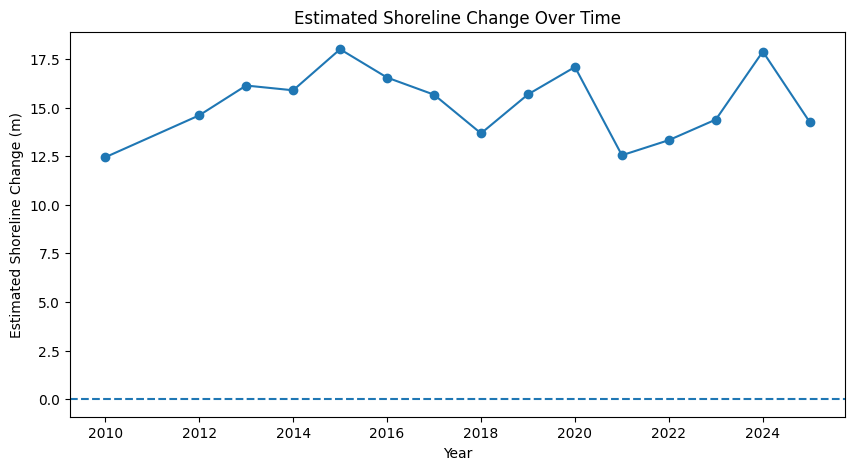

In [1531]:
plt.figure(figsize=(10,5))

plt.plot(
    shoreline_df["Year"],
    shoreline_df["Estimated_Shoreline_Shift_m"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Year")
plt.ylabel("Estimated Shoreline Change (m)")
plt.title("Estimated Shoreline Change Over Time")

plt.show()

# run - forecast future shoreline

In [1532]:
forecast_df = shoreline_df.copy()

forecast_df = forecast_df[["Year", "Estimated_Shoreline_Shift_m"]]
forecast_df

,Year,Estimated_Shoreline_Shift_m
0,2010,12.443381
1,2012,14.598592
2,2013,16.132353
3,2014,15.887324
4,2015,18.000000
5,2016,16.542857
6,2017,15.662037
7,2018,13.672727
8,2019,15.677155
9,2020,17.084991


In [1533]:
X = forecast_df["Year"].values.reshape(-1,1)
y = forecast_df["Estimated_Shoreline_Shift_m"].values

model = LinearRegression()

model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [1534]:
next_year = np.array([[2026]])

predicted_shift = model.predict(next_year)

print("Predicted shoreline shift for 2026:", predicted_shift[0], "meters")

Predicted shoreline shift for 2026: 15.228112868505942 meters


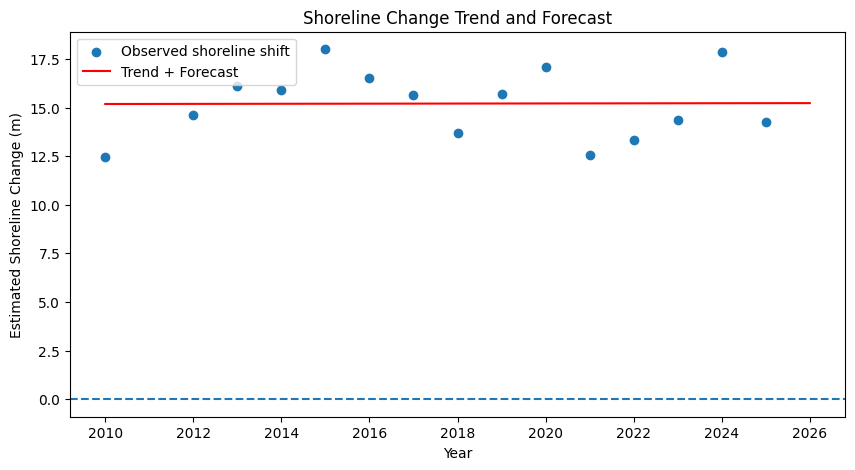

In [1535]:
years_extended = np.append(forecast_df["Year"].values, 2026).reshape(-1,1)
predictions = model.predict(years_extended)

plt.figure(figsize=(10,5))

plt.scatter(forecast_df["Year"], y, label="Observed shoreline shift")

plt.plot(years_extended, predictions, color="red", label="Trend + Forecast")

plt.axhline(0, linestyle="--")

plt.xlabel("Year")
plt.ylabel("Estimated Shoreline Change (m)")
plt.title("Shoreline Change Trend and Forecast")

plt.legend()
plt.show()

In [1536]:
erosion_rate = model.coef_[0]

print("Estimated shoreline change rate:", erosion_rate, "meters per year")

Estimated shoreline change rate: 0.00279242064422429 meters per year


# run - compute setback risk indicator

In [1537]:
setback_table = {
    "very low": {"reservation": 15, "restricted": 30},
    "low": {"reservation": 20, "restricted": 30},
    "moderate": {"reservation": 20, "restricted": 35},
    "high": {"reservation": 25, "restricted": 35}
}

In [1538]:
next_year_shift = predicted_shift[0]

predicted_retreat = abs(next_year_shift)

print("Predicted shoreline movement for next year:", predicted_retreat, "m")

Predicted shoreline movement for next year: 15.228112868505942 m


In [1539]:
reservation_distance = setback_table[cvi_level]["reservation"]
restricted_distance = setback_table[cvi_level]["restricted"]

print("Reservation area distance:", reservation_distance, "m")
print("Restricted area distance:", restricted_distance, "m")

Reservation area distance: 15 m
Restricted area distance: 30 m


In [1540]:
if predicted_retreat <= reservation_distance:

    zone = "Reservation Area (No Build Zone)"
    safety = "Safe"

elif predicted_retreat <= restricted_distance:

    zone = "Restricted Area (Soft Development Zone)"
    safety = "Caution"

else:

    zone = "Beyond Restricted Area"
    safety = "High Risk"

print("CVI Level:", cvi_level)
print("Predicted retreat next year:", round(predicted_retreat,2), "m")
print("Reservation limit:", reservation_distance, "m")
print("Restricted limit:", restricted_distance, "m")

print("Zone classification:", zone)
print("Risk status:", safety)

CVI Level: very low
Predicted retreat next year: 15.23 m
Reservation limit: 15 m
Restricted limit: 30 m
Zone classification: Restricted Area (Soft Development Zone)
Risk status: Caution
